---
# Variational Autoencoder 
---
In this exercise, we will implement a generative model called a **Variational Autoencoder (VAE)** and apply it to the AFHQ Cat dataset.

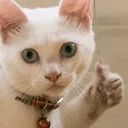

A VAE learns a latent distribution instead of a single deterministic feature vector. This allows us to reconstruct images, sample new images, and inspect how the latent space behaves.

You do not need to read the paper to complete the exercise, but it gives useful background on the reparameterization trick and variational training objective.  
Paper: [Auto-Encoding Variational Bayes](https://arxiv.org/abs/1312.6114)

---
# Imports
---

Run the code cell below after you have set up everything correctly (either locally or in Colab).

In [1]:
import torch
import importlib
import data
import trainer
import tests
import models
import visual
import utils

---
## Load and Visualize Data
---

Instead of CIFAR-10, we use the AFHQ Cat dataset. CIFAR-10 contains many different object classes and its cat images are very low-resolution and visually diverse, which makes the generation task unnecessarily difficult for this small generator setup. AFHQ Cats is better suited for learning a focused cat image distribution.

When `make_afhq_loaders` is called for the first time, the AFHQ dataset is downloaded and extracted. The cat images are then resized to the requested `image_size` and cached in a separate folder such as `afhq_v2_32/`. On later runs, this resized cache is reused. Finally, the resized cat images are loaded into memory as normalized tensors, which avoids repeatedly decoding and resizing the original high-resolution images during training.

Before training the model, we inspect a few validation images to verify that the data is loaded, resized, normalized, and batched correctly.

**Note:** After finishing the exercise, you can experiment with a higher `image_size` (e.g., 64 or 128) to see how the model performs on higher-resolution images. However, this will require more GPU memory and training time. You can also change the class name to `"dog"` or `"wild"` to train the model on different animal classes.

In [2]:
_, val_loader, _ = data.make_afhq_loaders(batch_size=8, num_workers=0, image_size=32)
x_true, _ = next(iter(val_loader))

visual._image_grid(x_true, title="AFHQ Cat validation images").show()

Extracting AFHQ v2:   0%|          | 0/15811 [00:00<?, ?file/s]

Creating resized AFHQ cache 32x32:   0%|          | 0/15803 [00:00<?, ?it/s]

AFHQ raw dir: /data/afhq_v2
AFHQ resized dir: /data/afhq_v2_32
AFHQ image size: 32x32
AFHQ cat train: 5065
AFHQ cat val: 246
AFHQ cat test: 247


---
## Theory
---

A Variational Autoencoder models data through a latent variable $z$. We assume a simple prior

$$
p(z) = \mathcal{N}(0, I).
$$

The encoder maps an input image $x$ to an approximate posterior over latent codes:

$$
q_\phi(z \mid x) = \mathcal{N}(z \mid \mu_{z|x}, \sigma^2_{z|x} I).
$$

In practice, the encoder predicts `mu` and `logvar`. To sample while keeping the model differentiable, we use the reparameterization trick:

$$
z = \mu_{z|x} + \sigma_{z|x} \odot \epsilon,
\quad
\epsilon \sim \mathcal{N}(0, I).
$$

The decoder defines a distribution over images given the latent code:

$$
p_\theta(x \mid z),
$$

and outputs a reconstruction $\hat{x}$. During training, the VAE learns to reconstruct $x$ while keeping $q_\phi(z \mid x)$ close to the prior $p(z)$.

---
## Model Architecture
---

The VAE consists of an encoder, two latent heads for $\mu$ and $\log\sigma^2$, a decoder, and a forward pass that reconstructs the input image.

We use `logvar` instead of `var` because the network may output any real value, while the variance must be positive. The variance is recovered by `exp(logvar)`.

### Architecture

The model encodes an input $x$ into the approximate posterior $q_\phi(z \mid x)$, samples $z$ using the reparameterization trick, and decodes $z$ into a reconstruction $\hat{x}$.
The architecture uses kernel size $4$, stride $2$, and padding $1$ for all downsampling and upsampling layers. Feel free to build your own network but this one works:

Encoder: 

$$
\begin{aligned}
(B,3,32,32) & \stackrel{\text{conv}}{\rightarrow} (B,32,16,16) + \texttt{LeakyReLU} \stackrel{\text{conv}}{\rightarrow} (B,64,8,8) + \texttt{BN} + \texttt{LeakyReLU} \\
& \stackrel{\text{conv}}{\rightarrow} (B,128,4,4) + \texttt{BN} + \texttt{LeakyReLU} \stackrel{\text{flatten}}{\rightarrow} (B,128\cdot4\cdot4)
\end{aligned}
$$

Two latent heads: 
$$
\begin{aligned}
(B,128\cdot4\cdot4) & \stackrel{\text{FC}}{\rightarrow} (B,128)\\
(B,128\cdot4\cdot4) & \stackrel{\text{FC}}{\rightarrow} (B,128)
\end{aligned}
$$

Decoder: 
$$
\begin{aligned}
(B,128) & \stackrel{\text{FC}}{\rightarrow} (B,128\cdot4\cdot4) \stackrel{\text{reshape}}{\rightarrow} (B,128,4,4) \stackrel{\text{conv}}{\rightarrow} (B,64,8,8) + \texttt{BN} + \texttt{ReLU}\\
& \stackrel{\text{conv}}{\rightarrow} (B,32,16,16) + \texttt{BN} + \texttt{ReLU} \stackrel{\text{conv}}{\rightarrow} (B,3,32,32) + \texttt{Tanh}
\end{aligned}
$$


## **Task:**

Implement `__init__`, `encode`, `reparameterize`, `decode`, `forward`, and `sample` in `models.py`.

**Hints:**
- Use the docstrings for expected arguments, shapes, and return values.
- The decoder needs a special CNN layer in order to increase the feature map size. Have a look at `torch.nn.ConvTranspose2d`. 
- A neural network can approximate anything that we want. Therefore, we can assume that it outputs directly $\log\sigma^2$ and treat the output like that!

In [3]:
importlib.reload(tests)
importlib.reload(models)
tests.test_vae_architecture()
tests.test_vae_modules()
tests.test_vae_reparameterize()

✅ PASS: VAE architecture and parameter count look correct.
✅ PASS: VAE encode/decode/forward/sample look correct.
✅ PASS: VAE reparameterization is correct.


True

---
## VAE Loss
---

The VAE is trained by minimizing the negative ELBO. The loss consists of two terms:

1. a reconstruction loss, which makes the reconstruction $\hat{x}$ close to the input $x$,
2. a KL loss, which keeps $q_\phi(z \mid x)$ close to the prior $p(z)=\mathcal{N}(0,I)$,

We maximize the ELBO
$$\log p_\theta(x) \geq \mathbb{E}_{q_\phi(z \mid x)}[\log p_\theta(x \mid z)] - D_{KL}(q_\phi(z \mid x) \| p(z)),$$
which is equivalent to minimize
$$- \log p_\theta(x) \leq - \mathbb{E}_{q_\phi(z \mid x)}[\log p_\theta(x \mid z)] + D_{KL}(q_\phi(z \mid x) \| p(z))$$

In this implementation, the encoder outputs the parameters of a diagonal Gaussian posterior $q_\phi(z \mid x)=\mathcal{N}(z \mid \mu, \Sigma)$,
where $\Sigma$ is a diagonal covariance matrix with entries $\sigma^2_i$ for $i=1,\ldots,d$.

## **Task:**

Show on paper, that $D_{KL}(q_\phi(z \mid x) \| p(z)) = \frac{1}{2} \sum_{i=1}^d (\mu_i^2 + \sigma_i^2 - 1 - \log \sigma_i^2)$ and then implement `vae_loss` in `trainer.py`.

**Hints:**
- Start from the definition of the [KL divergence](https://en.wikipedia.org/wiki/Kullback%E2%80%93Leibler_divergence).
- You will need the [multivariate normal distribution](https://en.wikipedia.org/wiki/Multivariate_normal_distribution) and basic properties of [expectations](https://en.wikipedia.org/wiki/Expected_value).
- MafI 1 reminder: [determinant](https://en.wikipedia.org/wiki/Determinant).
- It holds that $\mathbb{E}_{q_\phi(z \mid x)}[(z-\mu)^T\Sigma^{-1}(z-\mu)] = d$.
- It holds that $\mathbb{E}_{q_\phi(z \mid x)}[z^T z] = \operatorname{tr}(\Sigma)+\mu^T\mu$.
- For the reconstruction term $- \mathbb{E}_{q_\phi(z \mid x)}[\log p_\theta(x \mid z)]$, use the summed mean squared error. 
- Normalize both the reconstruction loss and the KL loss by the batch size.


### **Solution:**
Can be found in solution folder notebook.

In [4]:
importlib.reload(tests)
importlib.reload(trainer)
importlib.reload(models)
tests.test_vae_loss()

✅ PASS: VAE loss is correct.


True

---
## Training Step
---

## **Task:**
Implement `_step` in `trainer.py`.

**Hints:**
- If an optimizer is given, perform a training step with parameter updates. Otherwise, run an evaluation step without gradient computation. [This function](https://docs.pytorch.org/docs/2.12/generated/torch.autograd.grad_mode.set_grad_enabled.html) might be useful for this.

In [5]:
importlib.reload(tests)
importlib.reload(trainer)
importlib.reload(models)
tests.test_vae_step()

✅ PASS: VAE _step is correct.


True

---
## VAE Training Loop
---
We now want to train the VAE on AFHQ. We will ignore the original class labels. The model only learns to reconstruct images and organize the latent space.

In `trainer.py`, we have a training loop skeleton. `_loop` should run one full epoch over a data loader, call `_step` for each batch, and then return the average `loss`, `recon_loss`, and `kl_loss` over all samples. `train_vae` should create the AFHQ data loaders, initialize the VAE and optimizer, train for the given number of epochs, and store training and validation metrics in `history`.

## **Task:**

Implement `_loop` and `train_vae` in `trainer.py`.

In [7]:
importlib.reload(tests)
importlib.reload(trainer)
importlib.reload(models)

############################################
# TODO: Hyperparameters. Adjust these values to tune training.

latent_dim = 128            # The dimensionality of the latent space.
lr = .001                   # The learning rate for the optimizer.
weight_decay = .00005         # The weight decay (L2 regularization) for the optimizer.
batch_size = 64           # The number of samples per batch during training.
epochs = 200               # The number of epochs (full passes through the training dataset) to train the model.
image_size = 32           # The size of the input images (assumed to be square, so this is both width and height).
num_workers = 2          # The number of subprocesses to use for data loading. Set to 0 for no subprocesses.

############################################

device = torch.device("cuda:0" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() and torch.backends.mps.is_built() else "cpu")
print(f"Using device: {device}")

vae, history = trainer.train_vae(
    batch_size=batch_size,
    latent_dim=latent_dim,
    lr=lr,
    weight_decay=weight_decay,
    epochs=epochs,
    device=device,
    num_workers=num_workers,
    image_size=image_size
)

visual.show_training_stats(
    history,
    title="VAE Training",
).show()

Using device: cuda:0
AFHQ raw dir: /data/afhq_v2
AFHQ resized dir: /data/afhq_v2_32
AFHQ image size: 32x32
AFHQ cat train: 5065
AFHQ cat val: 246
AFHQ cat test: 247


---
## Reconstruction Check
---

After training, compare input images with their reconstructions. VAEs often produce blurry reconstructions, this is expected.

In [8]:
vae.eval()

with torch.no_grad():
    recon_x, _, _ = vae(x_true.to(device))

visual.vae_reconstructions(x_true.cpu(), recon_x.cpu()).show()

---
## Sampling New Images
---

A trained VAE can generate new images by sampling latent vectors from a standard normal distribution.

In [9]:
samples = vae.sample(num_samples=16, device=device)
visual._image_grid(samples.cpu(), title="VAE Samples").show()

---
## Latent Space Interpolation
---

We can generate smooth transitions between images by interpolating between two latent vectors $z_1$ and $z_2$.

A simple approach is linear interpolation: 
$$\alpha z_1 + (1 - \alpha) z_2,\quad \alpha \in [0,1].$$
However, linear interpolation may produce unrealistic samples if the straight path between $z_1$ and $z_2$ passes through low-density regions of the latent space.

Spherical linear interpolation (SLERP) addresses this by moving along the shortest path on the hypersphere instead of cutting directly through the latent space. This often yields smoother and more realistic transitions. When the two vectors are nearly parallel, linear interpolation is commonly used as a numerically stable fallback.
SLERP is defined as
$$
\frac{\sin((1-\alpha)\theta)}{\sin(\theta)}z_1 + \frac{\sin(\alpha\theta)}{\sin(\theta)}z_2,\quad \alpha \in [0,1]
$$
where
$$
\theta = \arccos \left( \frac{z_1^\top z_2}{\lVert z_1\rVert \lVert z_2\rVert} \right).
$$

## **Task:**

Implement `linear_interpolation` and `slerp_interpolation` in `utils.py`, and `interpolate` in `models.py`.

In [10]:

importlib.reload(tests)
importlib.reload(trainer)
importlib.reload(models)
importlib.reload(utils)
tests.test_vae_interpolate()

✅ PASS: VAE interpolation is correct.


True